In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd /content/drive/MyDrive/Colab Notebooks/cours_python/FSCI2610/projet/Finale

/content/drive/MyDrive/Colab Notebooks/cours_python/FSCI2610/projet/Finale


In [ ]:
import pandas as pd

df=pd.read_csv('voice_data.csv')
df.head()
print("Nombre total d'individus:", int(df.Group.count()))
df.Group.unique()

Nombre total d'individus: 108


array(['ASD', 'SLI', 'IC', 'TD'], dtype=object)

In [ ]:
#Étape Optionelle: suppression des données aberrantes.

import pandas as pd
import numpy as np

def drop_outliers_IQR(df):
    """
    Drops outliers from a DataFrame using the IQR method.

    Returns:
        pandas.DataFrame: The DataFrame with outliers removed.
    """
    # Select only numeric columns for outlier detection
    numeric_cols = df.select_dtypes(include=np.number).columns

    # Calculate quantiles and IQR only for numeric columns
    q1 = df[numeric_cols].quantile(0.25)
    q3 = df[numeric_cols].quantile(0.75)
    IQR = q3 - q1

    # Identify outliers based on numeric columns
    not_outliers = df[~((df[numeric_cols] < (q1 - 1.5 * IQR)) | (df[numeric_cols] > (q3 + 1.5 * IQR))).any(axis=1)]

    # Drop rows with missing values and reset index
    outliers_dropped = not_outliers.dropna().reset_index(drop=True)

    return outliers_dropped

df1 = df
df_outliers_dropped = drop_outliers_IQR(df1)
df = df_outliers_dropped
df_outliers_dropped

,Group,avg_f0,avg_F1,avg_F2,avg_F3,avg_F4,mean_hnr,jitter,shimmer,dispersion_formantique,avg_f0_k,mean_hnr_k,jitter_k,shimmer_k,dispersion_formantique_k,avg_f0_s,mean_hnr_s,jitter_s,shimmer_s,dispersion_formantique_s
0,ASD,294.45,662.70,1939.90,3251.25,4775.30,12.25,1.663247,1.389308,1370.866667,2.278845,3.440682,3.091686,3.108758,2.927942,0.133170,0.667077,0.560049,-0.244830,-0.390032
1,ASD,274.50,751.80,2276.35,3624.00,5020.65,12.05,1.348860,1.356875,1422.950000,3.840740,2.167156,2.126006,3.074187,2.465019,-0.699683,0.389802,0.466613,-0.184634,0.407536
2,ASD,334.10,684.90,2094.30,3579.70,4856.10,11.30,2.190127,1.458687,1390.400000,3.270168,2.770940,2.156335,2.384491,3.616185,0.073779,0.540132,-0.271603,-0.347822,0.721927
3,ASD,331.95,779.30,2271.30,3687.00,4806.70,9.30,1.989887,1.514565,1342.466667,3.788538,2.111079,3.193975,3.715863,2.814807,0.336245,-0.508081,0.757273,1.094934,0.379331
4,ASD,242.35,568.10,2164.15,3594.70,4882.15,12.00,1.274713,1.428855,1438.016667,3.649101,1.789300,2.814531,3.457994,4.223796,0.898138,-0.163299,0.562026,-0.154745,-0.122836
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,TD,283.45,974.90,2244.80,3577.80,4993.35,9.20,1.115663,1.298028,1339.483333,1.920708,2.484653,3.465841,4.570903,2.203718,0.236584,0.056520,0.744000,1.633419,-0.376739
68,TD,238.55,1105.40,2402.00,3511.10,4808.95,5.65,1.644070,1.665042,1234.516667,4.461122,4.636875,7.736325,2.372713,3.234770,-0.094724,1.152677,2.087395,0.497442,0.455561
69,TD,255.05,858.95,2223.80,3384.55,4787.25,9.75,1.111741,1.302515,1309.433333,5.190369,3.365465,1.875519,3.242620,1.881098,1.338850,0.806779,0.273689,-0.246472,0.152368
70,TD,266.45,762.45,2278.70,3557.60,4742.95,10.95,1.489093,1.517415,1326.833333,2.151113,2.531716,3.208905,2.385634,3.771958,0.114164,0.130736,0.951328,-0.507807,1.004282


In [ ]:
#On spécifie l'étude 1 ou l'étude 2
etude=2 #ou 2
ctrl_data = None

#Pour l'étude #1, on exclu le groupe 'IC' et 'SLI'
if etude == 1:
  #on exclu le groupe 'IC' et 'SLI'
  ctrl_data = df.loc[(df.Group != 'IC') & (df.Group != 'SLI')]
  print(f"Les groupes d'individus pour l'étude no. {etude} sont: {ctrl_data.Group.unique()}")
  print(f"Le nombre d'individus pour chaque type est: \n{ctrl_data.Group.value_counts()}")
else:
  #Pour l'etude #2, on inclu tous les individus
  ctrl_data = df.copy()
  print(f"Les groupes d'individus pour l'étude no. {etude} sont: {ctrl_data.Group.unique()}")
  print(f"Le nombre d'individus pour chaque type est: \n{ctrl_data.Group.value_counts()}")

#On renomme le group 'TD' à 'CTRL'
ctrl_data.loc[ctrl_data.Group == "TD", "Group"] = "CTRL"

#Pour l'étude no. 2, on doit renommer aussi le group 'IC' et 'SLI' à 'CTRL'
if etude == 2:
  #Pour l'étude #2, on renomme le group 'IC' et 'SLI'.  on a déjà renommer le groupe 'TD' ci-haut.
  ctrl_data.loc[ctrl_data.Group == "IC", "Group"] = "CTRL"
  ctrl_data.loc[ctrl_data.Group == "SLI", "Group"] = "CTRL"

y =ctrl_data["Group"]
print(f"\nLes individus du groupe pour l'étude no. {etude} sont: ", y.unique())
print(f"Le nombre d'individus pour chaque type sont: \n{ctrl_data.Group.value_counts()}")

#Pour les characteristiques, on inclus les 4 characteristiques suivante:
#print("\ctrl_data est:\n",ctrl_data)
X = ctrl_data.loc[:,['avg_F1', 'jitter_s', 'shimmer', 'mean_hnr']]

print("\nLes valeures 'y' sont:\n", y.value_counts())

print(f"\nLes valeurs de X sont:\n{X.count()}")

Les groupes d'individus pour l'étude no. 2 sont: ['ASD' 'SLI' 'IC' 'TD']
Le nombre d'individus pour chaque type est: 
Group
ASD    38
IC     25
TD     24
SLI    21
Name: count, dtype: int64

Les individus du groupe pour l'étude no. 2 sont:  ['ASD' 'CTRL']
Le nombre d'individus pour chaque type sont: 
Group
CTRL    70
ASD     38
Name: count, dtype: int64

Les valeures 'y' sont:
 Group
CTRL    70
ASD     38
Name: count, dtype: int64

Les valeurs de X sont:
avg_F1      108
jitter_s    108
shimmer     108
mean_hnr    108
dtype: int64


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

pca = PCA(n_components=4)
X_pca = pca.fit_transform(X)
print("Explained variance ratio:",(sum(pca.explained_variance_ratio_)))

X_Scaled = StandardScaler().fit_transform(X_pca)

#Convertir les classes en valeures binaires.
y_numeric = y.map({'ASD':1, 'CTRL':0})
print("\nLe nombre de d'individus(es) pour chaque catégorie:\n\n",y_numeric.value_counts())

print("\nIndividus(es) autistique:", np.count_nonzero(y_numeric == 1))
print("Individus(es) non autistique:", np.count_nonzero(y_numeric == 0))

print("\nX:",len(X_Scaled), "\ny_numeric:", len(y_numeric), "\n\n")
X=X_Scaled
y=y_numeric
print("y:\n", y)

Explained variance ratio: 0.9999999999999999

Le nombre de d'individus(es) pour chaque catégorie:

 Group
0    70
1    38
Name: count, dtype: int64

Individus(es) autistique: 38
Individus(es) non autistique: 70

X: 108 
y_numeric: 108 


y:
 0      1
1      1
2      1
3      1
4      1
      ..
103    0
104    0
105    0
106    0
107    0
Name: Group, Length: 108, dtype: int64


In [ ]:
#KMeans++ supervisé avec Cross Validation en utilisant le scoring ROC.
#il s'agit de guider KMeans++ pour aligner les étiquettes (predictions)
#avec les vraies valeures.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedShuffleSplit
from scipy.stats import mode
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, silhouette_score

# Initialiser StratifiedShuffleSplit Cross-Validation
strat_shuffle_split = StratifiedShuffleSplit(n_splits=400, test_size=0.3, random_state=84)

# Sauvegarder les valeurs ROC et scores and pour le calcul de la moyenne
tprs = []
mean_fpr = np.linspace(0, 1, 100)
thresholds=[]
accuracy_scores = []

# Sauvegarder les résultats confusion pour chaque 'split'
conf_matrices = []
optimalthreshold = 0.9
kmeans = KMeans(n_clusters=2, init="k-means++")

for i, (train_index, test_index) in enumerate(strat_shuffle_split.split(X, y)):
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    print("******************************")

    # On applique le clustering K-Means++
    kmeans.fit_transform(X_train)
    cluster_labels = kmeans.fit_predict(X_train)

    # On map les étiquettes du clustering avec les valeures vraies.
    mapping = {}
    for j in np.unique(cluster_labels):
        # On calcul le nombre de valeures vraies dans les étiquettes prédite
        # par le clustering KMeans++
        most_frequent_label = mode(y_train[cluster_labels == j], keepdims=True).mode[0]

        #  On assigne les étiquettes pour assurer deux étiquettes unique.
        if most_frequent_label in mapping.values() and list(mapping.keys())[list(mapping.values()).index(most_frequent_label)] != j:

            # On assigne l'étiquettes opposées. the opposite label
            mapping[j] = 1 - most_frequent_label
        else:
            mapping[j] = most_frequent_label

    mapped_preds = np.vectorize(mapping.get)(kmeans.predict(X_train))

    # On assure que les predictions (mapped_preds) et (y_test) contiennent seulement 0 ou 1
    mapped_preds = np.where(mapped_preds > 1, 1, mapped_preds)

    # On compare les étiquettes
    y_test_encoded = np.where(y_test > 1, 1, y_test)
    y_train_encoded = np.where(y_train > 1, 1, y_train)

    #On affiche la performance du 'fold'
    print(f"Fold {i+1}: \n")
    print("\nCluster Labels: \n", cluster_labels)
    print("\nKMeans++ Score: \n", kmeans.score(X_train))
    print("\nMapping predictions: \n", mapped_preds)
    print("\nGround Truth: \n", y_train_encoded)

    # Calcul accuracy score
    accuracy_score_fold = np.mean(mapped_preds == y_train_encoded)
    accuracy_scores.append(accuracy_score_fold)
    print("\nAccuracy Score: ", accuracy_score_fold)

    # On affiche le classification report
    print("\nClassification Report: \n", classification_report(y_train_encoded, mapped_preds))

    # On affiche le silhouette score
    current_silhouette_score = silhouette_score(X_train, mapped_preds)
    print("\nSilhouette Score: ", current_silhouette_score)

    # On calcul ROC
    fpr, tpr, thresholds_kmeans = roc_curve(y_train_encoded, mapped_preds)
    roc_auc = auc(fpr, tpr)
    print("\nROC_AUC: ", roc_auc, "\n")

    # Interpolatiin de tpr to have pour avoir la meême grandeur que mean_fpr
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

    # On sauvegarde le meilleur threshold (Youden’s J statistic)
    j_scores = tpr - fpr  # Valeur de maximum (TPR - FPR)
    best_threshold = thresholds_kmeans[np.argmax(j_scores)]
    thresholds.append(best_threshold)

    # On applique la fonction de décision pour calculer de la valeur optimal threshold
    # baser sur la distance minimale des centroids.
    distances = kmeans.transform(X_train)
    min_distances = np.min(distances, axis=1)

    # Applique la règle du Threshold pour prendre la decision.
    predicted_classes = (min_distances < optimalthreshold).astype(int)  # 1 if close, 0 if far

    # On calcul la matrice de confusion.
    cm = confusion_matrix(y_train_encoded, mapped_preds)

    # On assure que la matrice ee confusion est toujours de dimension 2x2
    if cm.shape != (2, 2):
        cm_padded = np.zeros((2, 2), dtype=int)
        cm_padded[:cm.shape[0], :cm.shape[1]] = cm
        cm = cm_padded

    conf_matrices.append(cm)
    print("\nConfusion Matrix: \n", cm)
    print("\n******************************\n")

# On calcul le ROC finale.
mean_tpr = np.mean(tprs, axis=0)
mean_auc = auc(mean_fpr, mean_tpr)

mean_accuracy = np.mean(accuracy_scores)
best_accuracy_index = np.argmax(accuracy_scores)
best_accuracy = accuracy_scores[best_accuracy_index]
print("Mean accuracy score: ", mean_accuracy)
print("Best accuracy score: ", best_accuracy)

# On calcul la moyenne des valeures de la mateice de confusion.
avg_conf_matrix = np.mean(conf_matrices, axis=0)

In [1]:
# On affiche la moyenne des valeurs de la matrice de confusion avec KMeans++ supervisë.

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

c_cm = cm
cm = avg_conf_matrix

print(avg_conf_matrix)
print(cm.shape[0])
print(cm.shape[1])
fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.matshow(cm, cmap=plt.cm.Blues, alpha=0.3)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(x=j, y=i,s=cm[i, j], va='center',
                ha='center', size='xx-large')

plt.xlabel('Predictions', fontsize=18)
plt.ylabel('Actuals', fontsize=18)
plt.title('Supervised KMeans++ with ROC Average Across Multiple Folds', fontsize=18)
plt.show()



NameError: name 'cm' is not defined

In [ ]:
#Approche Clustering-then-label avec KMeans++ et ensuite classification SVC avec
# cross validation ROC.

import numpy as np
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, cross_val_score, ShuffleSplit
from sklearn.metrics import accuracy_score, roc_auc_score, precision_recall_curve, classification_report, fowlkes_mallows_score, normalized_mutual_info_score, silhouette_score
from sklearn.model_selection import ShuffleSplit

rs = ShuffleSplit(n_splits=200, test_size=0.3)

#Creation du SVC pour la classification
model_SVC = SVC(kernel="linear", probability=True)

# On applique KMeans++ clustering avant que les données soient divisëes.
model_KMeans = KMeans(n_clusters=2, init="k-means++")
clustered_labels = model_KMeans.fit_predict(X, y)

#Evalue le  clustering
silhouette = silhouette_score(X, clustered_labels)
print("For model_KMeans: \n", model_KMeans.get_params(), "\nThe silhouette_score is :", silhouette)

# On applique le split train/test (70%/30%)
X_train, X_test, y_train, y_test = train_test_split(X, clustered_labels, test_size=0.3, random_state=84)

# On applique classification SVC training data and perform cross-validation.
scores = cross_val_score(model_SVC, X_train, y_train, cv=rs, verbose=5, scoring='roc_auc')
scores = scores[~np.isnan(scores)]
print("\nSVC classification with cross-validation and ROC scoring: ", np.mean(scores))

#Display results
y_pred = model_SVC.fit(X_train, y_train).predict(X_train)
print("\nAccuracy Score: ", accuracy_score(y_train, y_pred))
print("\nClassification Report: \n", classification_report(y_train, y_pred))

For model_KMeans: 
 {'algorithm': 'lloyd', 'copy_x': True, 'init': 'k-means++', 'max_iter': 300, 'n_clusters': 2, 'n_init': 'auto', 'random_state': None, 'tol': 0.0001, 'verbose': 0} 
The silhouette_score is : 0.17211989351541443
[CV] END ................................ score: (test=1.000) total time=   0.0s
[CV] END ................................ score: (test=0.992) total time=   0.0s
[CV] END ................................ score: (test=1.000) total time=   0.0s
[CV] END ................................ score: (test=1.000) total time=   0.0s
[CV] END ................................ score: (test=0.992) total time=   0.0s
[CV] END ................................ score: (test=1.000) total time=   0.0s
[CV] END ................................ score: (test=1.000) total time=   0.0s
[CV] END ................................ score: (test=1.000) total time=   0.0s
[CV] END ................................ score: (test=1.000) total time=   0.0s
[CV] END ................................

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.3s


[CV] END ................................ score: (test=1.000) total time=   0.0s
[CV] END ................................ score: (test=1.000) total time=   0.0s
[CV] END ................................ score: (test=1.000) total time=   0.0s
[CV] END ................................ score: (test=1.000) total time=   0.0s
[CV] END ................................ score: (test=1.000) total time=   0.0s
[CV] END ................................ score: (test=1.000) total time=   0.0s
[CV] END ................................ score: (test=1.000) total time=   0.0s
[CV] END ................................ score: (test=1.000) total time=   0.0s
[CV] END ................................ score: (test=1.000) total time=   0.0s
[CV] END ................................ score: (test=1.000) total time=   0.0s
[CV] END ................................ score: (test=1.000) total time=   0.0s
[CV] END ................................ score: (test=1.000) total time=   0.0s
[CV] END ...................

[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.6s


Prediction True:  33
Ground Truth:  34
[[41  0]
 [ 1 33]]
2
2


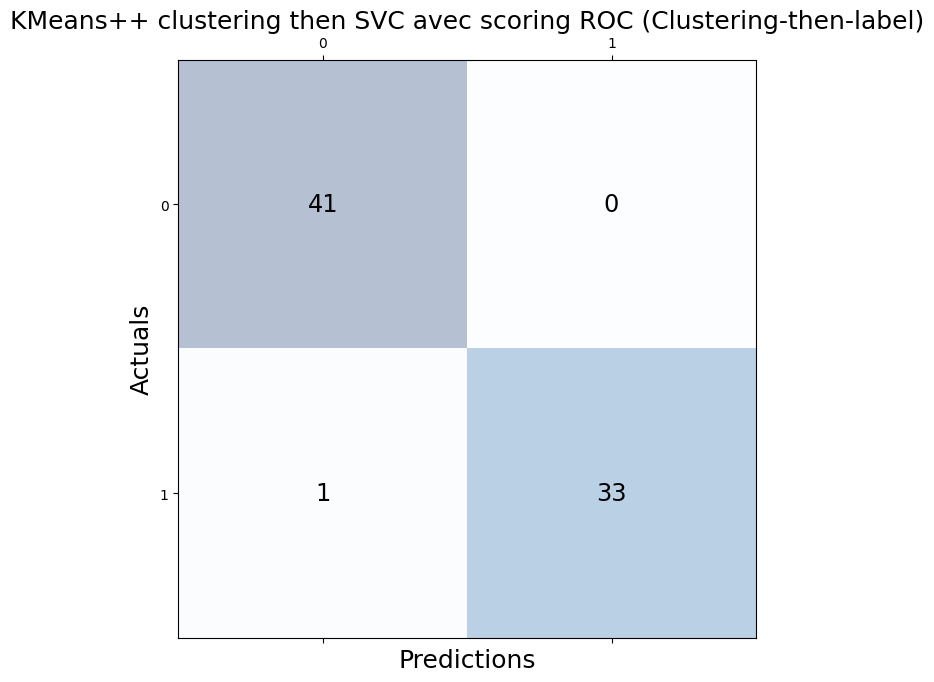

In [ ]:
# On affiche la matrice de confusion pour le clustering-then-label
#(KMeans++ ensuite SVC)
print("Prediction True: ", list(y_pred).count(1))
print("Ground Truth: ", list(y_train).count(1))
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_train, y_pred)
print(cm)
print(cm.shape[0])
print(cm.shape[1])
fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.matshow(cm, cmap=plt.cm.Blues, alpha=0.3)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(x=j, y=i,s=cm[i, j], va='center',
                ha='center', size='xx-large')

plt.xlabel('Predictions', fontsize=18)
plt.ylabel('Actuals', fontsize=18)
plt.title("KMeans++ clustering then SVC avec scoring ROC (Clustering-then-label)", fontsize=18)
plt.show()

# Compute Average Confusion Matrix
#avg_conf_matrix = np.mean(conf_matrices, axis=0)



In [ ]:
import pickle

# Save the model to a file
with open("model_SVC.pkl", "wb") as f:
    pickle.dump(model_SVC, f)

In [ ]:
!ls -lta

total 3735
-rw------- 1 root root  472613 Mar 27 18:22 Supervised_KMeans++_ROC.ipynb
-rw------- 1 root root    1976 Mar 27 17:58 model_SVC.pkl
-rw------- 1 root root    1716 Mar 27 17:53 model.pkl
-rw------- 1 root root  902759 Mar 27 15:48 Baseline.ipynb
-rw------- 1 root root   79176 Mar 27 14:55 preprocessing_feature_selection.ipynb
drwx------ 2 root root    4096 Mar 26 16:20 NEAT
-rw------- 1 root root 1204960 Mar 25 06:42 MFCC-extraction.ipynb
-rw------- 1 root root  150710 Mar 21 00:16 SNN_ROC.ipynb
-rw------- 1 root root  978716 Mar  6 17:43 MFCC.ipynb
-rw------- 1 root root   21709 Feb 19 08:24 voice_data.csv
-rw------- 1 root root    2837 Feb  4 22:07 Tip_Fuzzy_Logic.ipynb


**Attention**: Le reste du code était un essai de deployer FastAPI à l'interieur de Google Colab. il m'est devenu apparent après essaies et recherche que celà n'est pas possible. La limite de l'environment Google Colab atteinte, j'ai brancher avec Python strictement(eg .py) avec Streamlit et Flask.  Mais, après quelques heures d'effort et puisque l'obectif du projet est de concevoir au minimun un réseau neurones, j'ai ré-orienté mes efforts vers le développement du réseau neurones et sauvegarder les modèles ci-haut (model.pkl et model_SVC.pkl).  


**Important**: J'ai aussi pris soin de ne pas inclure l'application conçu avec FastAPI (App.py), elle fut donc supprimée.  J'ai opter de garder le code ci-bas pour référence future, s'il a lieu ou intérêt.


**Donc, il est donc avisable d'ignorer le reste du code et vous dirigez vers le prochain notebook intituler SNN_ROC.ipynb.**, implémentation d'un réseau neurones simple.

In [ ]:
pip install fastapi fastapi[standard] uvicorn pydantic-settings


In [ ]:
!pip install fastapi[standard]
!fastapi run ./main.py

]11;?\]10;?\
   FastAPI   Starting production server 🚀
 
             Searching for package file structure from directories with __init__.py files
 
             Path does not exist main.py



In [ ]:
!uvicorn main:app --reload

INFO:     Will watch for changes in these directories: ['/content/drive/MyDrive/Colab Notebooks/cours_python/FSCI2610/projet']
INFO:     Uvicorn running on http://127.0.0.1:8000 (Press CTRL+C to quit)
INFO:     Started reloader process [1398] using WatchFiles
Process SpawnProcess-1:
Traceback (most recent call last):
  File "/usr/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.11/dist-packages/uvicorn/_subprocess.py", line 80, in subprocess_started
    target(sockets=sockets)
  File "/usr/local/lib/python3.11/dist-packages/uvicorn/server.py", line 66, in run
    return asyncio.run(self.serve(sockets=sockets))
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/asyncio/runners.py", line 190, in run
    return runner.run(main)
           ^^^^^^^^^^^^^^^^
  File "/usr/lib/python

In [ ]:
!pwd

/content/drive/MyDrive/Colab Notebooks/cours_python/FSCI2610/projet/Finale


In [ ]:
from fastapi import FastAPI, Body
from pydantic import BaseModel
import pickle
import numpy as np
import uvicorn
import os # Import the os module
from dotenv import load_dotenv
from threading import Lock
from typing import Annotated

# Initialize the FastAPI app
app = FastAPI()

load_dotenv()

# Set the server-side timeout
app.state.timeout = int(os.getenv("TIMEOUT", 300))  # 5 minutes

# Define the app state
app.state.APP_STATE = "ready"
app.state.lock = Lock()

# Load the trained model
with open("model.pkl", "rb") as f:
    model = pickle.load(f)

class InputData(BaseModel):
    feature1: float
    feature2: float
    feature3: float
    feature4: float

# Now app is defined and can be used with the decorator
@app.post("/predict")
async def predict(data: InputData): # Use InputData for type hinting and validation
    #data = pydantic.model_dump(data)
    data_dict = data.model_dump()
    with app.state.lock:
        # If app state is not ready, then wait until ready
        if app.state.APP_STATE != "ready":
            return {"message": "App is currently in use. Please try again later."}

        app.state.APP_STATE = "modifying"

        # Extract features from the InputData object
        input_features = np.array([data_dict["feature1"], data_dict["feature2"], data_dict["feature3"], data_dict["feature4"]]).reshape(1, -1)

        # Make prediction
        prediction = model.predict(input_features)

        app.state.APP_STATE = "ready"
        return {"prediction": prediction[0]} # Return prediction as a single value

In [ ]:
!pip install pyngrok
!ngrok config add-authtoken 2uPkoD4d7qYWek6DE2oUwXR1ipR_6ke3mBr9jfNmzHn8k9Z5E

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
import os
import sys
from fastapi import FastAPI
from fastapi.logger import logger
from pydantic_settings import BaseSettings
from typing import Literal # Import Literal
from pyngrok import ngrok

class Settings(BaseSettings):
    # ... The rest of our FastAPI settings

    BASE_URL: Literal["http://localhost:8003"] = "http://localhost:8003" # Added type annotation
    USE_NGROK: bool = os.environ.get("USE_NGROK", "False") == "True"
    content_type: str = "application/json" # Added content_type attribute

settings = Settings()

def init_webhooks(base_url):
    # Update inbound traffic via APIs to use the public-facing ngrok URL
    pass

if settings.USE_NGROK and os.environ.get("NGROK_AUTHTOKEN"):
    # pyngrok should only ever be installed or initialized in a dev environment when this flag is set

    # Get the dev server port (defaults to 8000 for Uvicorn, can be overridden with `--port`
    # when starting the server
    port = sys.argv[sys.argv.index("--port") + 1] if "--port" in sys.argv else "8003"

    # Open a ngrok tunnel to the dev server
    public_url = ngrok.connect(port).public_url
    logger.info(f"ngrok tunnel \"{public_url}\" -> \"http://127.0.0.1:{port}\"")

    # Update any base URLs or webhooks to use the public ngrok URL
    settings.BASE_URL = public_url # This line might need adjustment based on how you want to use the public URL
    init_webhooks(public_url)




In [ ]:
import threading
import time
import socket
import uvicorn

config = uvicorn.Config(app=app)
server = uvicorn.Server(config=config)
(sock := socket.socket()).bind(("localhost", 8003))
thread = threading.Thread(target=server.run, kwargs={"sockets": [sock]})
thread.start()  # non-blocking call

while not server.started:
    time.sleep(0.001)

address, port = sock.getsockname()
print(f"HTTP server is now running on http://{address}:{port}")

INFO:     Started server process [160]
INFO:     Waiting for application startup.
INFO:     Application startup complete.


HTTP server is now running on http://127.0.0.1:8003


In [ ]:
import requests
import json

url = 'http://127.0.0.1:8003/predict'
#m_data = '[778.00, 1.377360, 1.205160, 10.75]'

input_data = InputData(feature1=778.00, feature2=1.377360, feature3=1.20516, feature4=10.75)
data_dict = input_data.model_dump()

resp = requests.post(url=url, json=data_dict)

# Check the status code before attempting to decode JSON
if resp.status_code == 200:
    print(resp.json())
else:
    print(f"Request failed with status code: {resp.status_code}")
    print("My error: ", resp.text) # Print the raw response for debugging

INFO:     127.0.0.1:59326 - "POST /predict HTTP/1.1" 500 Internal Server Error


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/fastapi/encoders.py", line 324, in jsonable_encoder
    data = dict(obj)
           ^^^^^^^^^
TypeError: 'numpy.int32' object is not iterable

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/fastapi/encoders.py", line 329, in jsonable_encoder
    data = vars(obj)
           ^^^^^^^^^
TypeError: vars() argument must have __dict__ attribute

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 409, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/uvicorn/middleware/proxy_headers.py", line 60

Request failed with status code: 500
My error:  Internal Server Error


In [ ]:
!uvicorn main:app --reload

INFO:     Will watch for changes in these directories: ['/content/drive/MyDrive/Colab Notebooks/cours_python/FSCI2610/projet/Finale']
INFO:     Uvicorn running on http://127.0.0.1:8000 (Press CTRL+C to quit)
INFO:     Started reloader process [12810] using WatchFiles
ERROR:    Error loading ASGI app. Could not import module "main".
INFO:     Stopping reloader process [12810]


In [ ]:
!ps -ef | grep socket

root          85       6  0 17:44 ?        00:00:03 /usr/local/bin/dap_multiplexer --domain_socket_p
root       12879     160  0 18:35 ?        00:00:00 /bin/bash -c ps -ef | grep socket
root       12881   12879  0 18:35 ?        00:00:00 grep socket


In [ ]:
#!docker --version
#!dockerd
!kill -9 1261

In [ ]:
!netstat

Active Internet connections (w/o servers)
Proto Recv-Q Send-Q Local Address           Foreign Address         State      
tcp        0      0 e20d39f4ee92:6000       e20d39f4ee92:58122      TIME_WAIT  
tcp        0      0 e20d39f4ee92:34306      nuq04s19-in-f10.1e1:443 ESTABLISHED
tcp        0      0 e20d39f4ee92:60226      slc08s09-in-f10.1e1:443 ESTABLISHED
tcp        1      0 localhost:59326         localhost:8003          CLOSE_WAIT 
tcp        0      0 e20d39f4ee92:56472      slc18s06-in-f10.1e1:443 ESTABLISHED
tcp        1      0 e20d39f4ee92:46960      qro02s12-in-f10.1e1:443 CLOSE_WAIT 
tcp        0      0 localhost:43013         localhost:49012         ESTABLISHED
tcp        0      0 e20d39f4ee92:6000       e20d39f4ee92:55136      TIME_WAIT  
tcp        0      0 e20d39f4ee92:6000       e20d39f4ee92:32798      ESTABLISHED
tcp        0      0 e20d39f4ee92:35316      172.28.0.1:8009         ESTABLISHED
tcp        0      0 e20d39f4ee92:47430      slc09s01-in-f10.1e1:443 ESTABLISHE

In [ ]:
print('data={"feature1":778.00, "feature2":1.377360,"feature3":1.205160, "feature4":10.75}')

"""

1    662.70  1.389308  0.560049     12.25
2    884.55  1.185426  0.722608     12.90
3    652.05  1.645441  0.045519      8.65
4    739.75  1.544171  1.151768      8.30

"""

data={"feature1":778.00, "feature2":1.377360,"feature3":1.205160, "feature4":10.75}


'\n\n1    662.70  1.389308  0.560049     12.25\n2    884.55  1.185426  0.722608     12.90\n3    652.05  1.645441  0.045519      8.65\n4    739.75  1.544171  1.151768      8.30\n\n'

In [ ]:
!apt-get update
!apt-get install docker.io -y # Update apt and install Docker if not present
!pip install docker #Install docker python client

import os
import subprocess

# Ensure Docker daemon is running
os.system('systemctl start docker')

command = ['docker', 'buildx', '-t', 'app', './Dockerfile']
x = subprocess.check_output(command)
print(x.decode('utf-8'))

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,684 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [4,049 kB]
Get:11 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,381 kB]
Hit:12 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:13 https://ppa.launchpadconten

CalledProcessError: Command '['docker', 'buildx', '-t', 'app', './Dockerfile']' returned non-zero exit status 125.

In [ ]:
import os
import subprocess

# Verify Docker is running by checking its status
status = os.system('docker ps > /dev/null 2>&1')

# Start Docker if it's not running
if status != 0:
  print("Starting Docker...")
  !docker start ./Dockerfile # Start docker service if not already active

command = ['docker', 'build', '-t', 'main:app', '.']
try:
    x = subprocess.check_output(command, stderr=subprocess.STDOUT)
    print(x.decode('utf-8'))
except subprocess.CalledProcessError as e:
    print(f"Error during Docker build: {e}")
    print(f"Output: {e.output.decode('utf-8')}")

Starting Docker...
Cannot connect to the Docker daemon at unix:///var/run/docker.sock. Is the docker daemon running?
Error: failed to start containers: ./Dockerfile
Error during Docker build: Command '['docker', 'build', '-t', 'main:app', '.']' returned non-zero exit status 1.
Output: DEPRECATED: The legacy builder is deprecated and will be removed in a future release.
            Install the buildx component to build images with BuildKit:
            https://docs.docker.com/go/buildx/

unable to prepare context: unable to evaluate symlinks in Dockerfile path: lstat /content/drive/MyDrive/Colab Notebooks/cours_python/FSCI2610/projet/Finale/Dockerfile: no such file or directory



In [ ]:
!update-alternatives --config iptables

#!dockerd --debug

#!dockerd -h
#!whoami

There are 2 choices for the alternative iptables (providing /usr/sbin/iptables).

  Selection    Path                       Priority   Status
------------------------------------------------------------
* 0            /usr/sbin/iptables-nft      20        auto mode
  1            /usr/sbin/iptables-legacy   10        manual mode
  2            /usr/sbin/iptables-nft      20        manual mode

Press <enter> to keep the current choice[*], or type selection number: ^C


In [ ]:

!pip install udocker
!udocker --allow-root install

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.6/119.6 kB 4.4 MB/s eta 0:00:00
Info: creating repo: /root/.udocker
Info: udocker command line interface 1.3.17
Info: searching for udockertools >= 1.2.11
Info: installing udockertools 1.2.11
Info: installation of udockertools successful


In [ ]:
!udocker --allow-root run app

Error: manifest not found or not authorized
Error: no files downloaded
Error: image or container not available


In [ ]:
#!udocker --allow-root debug
#!udocker --allow-root run app

!dockerd
!docker buildx build -t app ./Dockerfile

INFO[2025-03-27T18:37:16.970571734Z] Starting up                                  
INFO[2025-03-27T18:37:16.971478320Z] containerd not running, starting managed containerd 
INFO[2025-03-27T18:37:16.972889194Z] started new containerd process                address=/var/run/docker/containerd/containerd.sock module=libcontainerd pid=14545
INFO[2025-03-27T18:37:17.069740165Z] starting containerd                           revision= version=1.7.24
INFO[2025-03-27T18:37:17.134860821Z] loading plugin "io.containerd.snapshotter.v1.aufs"...  type=io.containerd.snapshotter.v1
INFO[2025-03-27T18:37:17.157561534Z] skip loading plugin "io.containerd.snapshotter.v1.aufs"...  error="aufs is not supported (modprobe aufs failed: exit status 1 \"modprobe: FATAL: Module aufs not found in directory /lib/modules/6.1.85+\\n\"): skip plugin" type=io.containerd.snapshotter.v1
INFO[2025-03-27T18:37:17.157625591Z] loading plugin "io.containerd.event.v1.exchange"...  type=io.containerd.event.v1
INFO[2025-03-27T18

In [ ]:
import os
import subprocess

# Ensure Docker daemon is running
os.system('systemctl start docker')

command = ['docker', 'buildx', 'build', '-t', 'ai-model-app', '.']
# Capture both stdout and stderr for debugging
try:
    x = subprocess.check_output(command, stderr=subprocess.STDOUT)
    print(x.decode('utf-8'))
except subprocess.CalledProcessError as e:
    print(f"Error during Docker build: {e}")
    print(f"Output: {e.output.decode('utf-8')}")

Error during Docker build: Command '['docker', 'buildx', 'build', '-t', 'ai-model-app', '.']' returned non-zero exit status 125.
Output: unknown shorthand flag: 't' in -t
See 'docker --help'.

Usage:  docker [OPTIONS] COMMAND

A self-sufficient runtime for containers

Common Commands:
  run         Create and run a new container from an image
  exec        Execute a command in a running container
  ps          List containers
  build       Build an image from a Dockerfile
  pull        Download an image from a registry
  push        Upload an image to a registry
  images      List images
  login       Log in to a registry
  logout      Log out from a registry
  search      Search Docker Hub for images
  version     Show the Docker version information
  info        Display system-wide information

Management Commands:
  builder     Manage builds
  checkpoint  Manage checkpoints
  container   Manage containers
  context     Manage contexts
  image       Manage images
  manifest    Manage

In [ ]:
import os
os.system(f'docker run -d -p 8000:8000 {app}')
os.system('docker ps')
os.system('docker exec -it 32512 bash')

256

In [ ]:
!dockerd

INFO[2025-03-27T18:37:41.795375757Z] Starting up                                  
INFO[2025-03-27T18:37:41.796381679Z] containerd not running, starting managed containerd 
INFO[2025-03-27T18:37:41.797929395Z] started new containerd process                address=/var/run/docker/containerd/containerd.sock module=libcontainerd pid=14721
INFO[2025-03-27T18:37:41.834139167Z] starting containerd                           revision= version=1.7.24
INFO[2025-03-27T18:37:41.859504146Z] loading plugin "io.containerd.snapshotter.v1.aufs"...  type=io.containerd.snapshotter.v1
INFO[2025-03-27T18:37:41.862521954Z] skip loading plugin "io.containerd.snapshotter.v1.aufs"...  error="aufs is not supported (modprobe aufs failed: exit status 1 \"modprobe: FATAL: Module aufs not found in directory /lib/modules/6.1.85+\\n\"): skip plugin" type=io.containerd.snapshotter.v1
INFO[2025-03-27T18:37:41.862563369Z] loading plugin "io.containerd.event.v1.exchange"...  type=io.containerd.event.v1
INFO[2025-03-27T18

In [ ]:
%%shell

sudo apt update -qq

sudo apt install apt-transport-https ca-certificates curl software-properties-common -qq

curl -fsSL https://download.docker.com/linux/ubuntu/gpg | sudo apt-key add -

sudo add-apt-repository "deb [arch=amd64] https://download.docker.com/linux/ubuntu bionic stable"

sudo apt update -qq

sudo apt install docker-ce

docker -a



In [ ]:
!docker ps -a

Cannot connect to the Docker daemon at unix:///var/run/docker.sock. Is the docker daemon running?


In [ ]:
!apt update

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
38 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InR

In [ ]:
!apt-get remove docker.io -y # Uninstall Docker if present
!apt-get remove udocker -y # Uninstall Docker if present

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following packages were automatically installed and are no longer required:
  apparmor bridge-utils containerd dns-root-data dnsmasq-base iptables libip6tc2
  libnetfilter-conntrack3 libnfnetlink0 libnftnl11 netcat netcat-openbsd runc ubuntu-fan
Use 'apt autoremove' to remove them.
The following packages will be REMOVED:
  docker.io
0 upgraded, 0 newly installed, 1 to remove and 38 not upgraded.
After this operation, 124 MB disk space will be freed.
(Reading database ... 127069 files and directories currently installed.)
Removing docker.io (26.1.3-0ubuntu1~22.04.1) ...
'/usr/share/docker.io/contrib/nuke-graph-directory.sh' -> '/var/lib/docker/nuke-graph-directory.sh'
invoke-rc.d: unknown initscript, /etc/init.d/docker not found.
invoke-rc.d: could not determine current runlevel
Processing triggers for man-db (2.10.2-1) ...
Reading package lists... Done
Building dependency tree... Done
R

In [ ]:
!apt-get update
!apt-get install docker.io -y # Update apt and install Docker if not present
!pip install docker #Install docker python client

Hit:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading

In [ ]:
# Ensure Docker daemon is running
import os
import subprocess
x=subprocess.check_output('systemctl start docker')
print(x.decode('Utf-8'))

FileNotFoundError: [Errno 2] No such file or directory: 'systemctl start docker'

In [ ]:
!sudo apt update
!sudo apt install docker.io

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
38 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InR

In [ ]:
!sudo apt-get remove containerd.io
!sudo apt install docker.io docker-compose -y
!systemctl start docker
!sudo gpasswd -a $USER docker

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
E: Unable to locate package containerd.io
E: Couldn't find any package by glob 'containerd.io'
E: Couldn't find any package by regex 'containerd.io'
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
docker.io is already the newest version (26.1.3-0ubuntu1~22.04.1).
The following additional packages will be installed:
  python3-attr python3-certifi python3-chardet python3-docker
  python3-dockerpty python3-docopt python3-dotenv python3-idna
  python3-jsonschema python3-pyrsistent python3-requests python3-setuptools
  python3-texttable python3-urllib3 python3-websocket python3-yaml
Suggested packages:
  python-attr-doc python-jsonschema-doc python3-openssl python3-socks
  python-requests-doc python-setuptools-doc
The following NEW packages will be installed:
  docker-compose python3-attr python3-certifi python3-chardet python3-docker
  python3-do

In [ ]:
!systemctl start docker

System has not been booted with systemd as init system (PID 1). Can't operate.
Failed to connect to bus: Host is down


In [ ]:
!docker -v

Docker version 26.1.3, build 26.1.3-0ubuntu1~22.04.1


In [ ]:
!docker pull ghost:4.8.0

Cannot connect to the Docker daemon at unix:///var/run/docker.sock. Is the docker daemon running?


In [ ]:
!systemctl status docker

System has not been booted with systemd as init system (PID 1). Can't operate.
Failed to connect to bus: Host is down


In [ ]:
!sudo usermod -aG docker root

In [ ]:
!dockerd

INFO[2025-03-27T18:40:25.090310131Z] Starting up                                  
INFO[2025-03-27T18:40:25.091273757Z] containerd not running, starting managed containerd 
INFO[2025-03-27T18:40:25.092661137Z] started new containerd process                address=/var/run/docker/containerd/containerd.sock module=libcontainerd pid=20309
INFO[2025-03-27T18:40:25.133533192Z] starting containerd                           revision= version=1.7.24
INFO[2025-03-27T18:40:25.181962935Z] loading plugin "io.containerd.snapshotter.v1.aufs"...  type=io.containerd.snapshotter.v1
INFO[2025-03-27T18:40:25.186916366Z] skip loading plugin "io.containerd.snapshotter.v1.aufs"...  error="aufs is not supported (modprobe aufs failed: exit status 1 \"modprobe: FATAL: Module aufs not found in directory /lib/modules/6.1.85+\\n\"): skip plugin" type=io.containerd.snapshotter.v1
INFO[2025-03-27T18:40:25.186978596Z] loading plugin "io.containerd.event.v1.exchange"...  type=io.containerd.event.v1
INFO[2025-03-27T18

In [ ]:
!/etc/init.d/docker start

/bin/bash: line 1: /etc/init.d/docker: No such file or directory


In [ ]:
!docker -v

Docker version 26.1.3, build 26.1.3-0ubuntu1~22.04.1


In [ ]:
!docker run app

docker: Cannot connect to the Docker daemon at unix:///var/run/docker.sock. Is the docker daemon running?.
See 'docker run --help'.


In [ ]:
%%shell
set -x
dockerd -b none --iptables=0 -l warn &
for i in $(seq 5); do [ ! -S "/var/run/docker.sock" ] && sleep 2 || break; done
docker info
docker network ls
docker pull hello-world
docker images
docker run hello-world
kill $(jobs -p)

++ seq 5
+ dockerd -b none --iptables=0 -l warn
+ for i in $(seq 5)
+ '[' '!' -S /var/run/docker.sock ']'
+ break
+ docker info
Client:
 Version:    26.1.3
 Context:    default
 Debug Mode: false

Server:
ERROR: Cannot connect to the Docker daemon at unix:///var/run/docker.sock. Is the docker daemon running?
errors pretty printing info
+ docker network ls
Cannot connect to the Docker daemon at unix:///var/run/docker.sock. Is the docker daemon running?
+ docker pull hello-world
Using default tag: latest
Cannot connect to the Docker daemon at unix:///var/run/docker.sock. Is the docker daemon running?
+ docker images
Cannot connect to the Docker daemon at unix:///var/run/docker.sock. Is the docker daemon running?
+ docker run hello-world
ERRO[2025-03-27T18:40:45.554623990Z] failed to mount overlay: invalid argument     storage-driver=overlay2
ERRO[2025-03-27T18:40:45.554797245Z] exec: "fuse-overlayfs": executable file not found in $PATH  storage-driver=fuse-overlayfs
WARN[2025-03-27T18:40

In [ ]:
!curl localhost:7001

curl: (7) Failed to connect to localhost port 7001 after 0 ms: Connection refused


In [ ]:
!docker build ./Dockerfile

DEPRECATED: The legacy builder is deprecated and will be removed in a future release.
            Install the buildx component to build images with BuildKit:
            https://docs.docker.com/go/buildx/

unable to prepare context: path "./Dockerfile" not found
